In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [38]:
df = pd.read_excel("/content/DATA_VENTAS.xlsx")

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3296 entries, 0 to 3295
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CORTE                    3296 non-null   object        
 1   FABRICANTE               3296 non-null   object        
 2   ID                       3296 non-null   object        
 3   PRODUCTO                 3296 non-null   object        
 4   AÑO1                     3296 non-null   int64         
 5   SEMANA                   3296 non-null   int64         
 6   MES                      3296 non-null   int64         
 7   FECHAW                   3296 non-null   datetime64[ns]
 8   FECHAM                   3296 non-null   datetime64[ns]
 9   VENTA_VALOR              3296 non-null   float64       
 10  LITROS                   3296 non-null   int64         
 11  PRECIO_UNITARIO_LITRO    3293 non-null   float64       
 12  PAQUETES                 3296 non-

Se observa que la base de datos está casi completa, a excepción de datos vacíos contenidos en el precio unitario por litro. Esto se puede resolver si se tiene la información adecuada de la venta y de los litros por producto, por lo que primero se buscará cuál es el problema con esos datos.

También se buscaría hacer un concatenado entre el año y el mes, de tal manera que al agrupar de forma mensual no existan errores entre años y sea un poco más sencillo de manipular los datos.

In [40]:
df['Fecha_W'] = df['AÑO1'].astype(str) + "-"+ df['SEMANA'].astype(str)
df['Fecha_M'] = df['AÑO1'].astype(str) + "-"+ df['MES'].astype(str)

In [41]:
df[df['PRECIO_UNITARIO_LITRO'].isnull()]

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE,Fecha_W,Fecha_M
1309,TN,FAB1,Leche Clasica Semi 1 L,FAB1_Leche Clasica Semi 1 L,2024,16,4,2024-04-15,2024-04-01,0.0,192,NaN,16,NaN,12,2024-16,2024-4
1659,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2025,4,1,2025-01-20,2025-01-01,-268.0,0,NaN,0,NaN,12,2025-4,2025-1
3268,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,17,4,2025-04-21,2025-04-01,0.0,0,NaN,0,NaN,12,2025-17,2025-4


In [45]:
df.groupby('ID')['PRODUCTO'].nunique().sort_values(ascending=False).head(20)

,PRODUCTO
ID,
100 70+30,1
100 Low C Arb,1
Des Light Deslactosada Light 1L,1
Deslac Deslactosada 1 L,1
ENTERA 1.5LT 10PZ,1
Entera Entera 1 L,1
Light Light 1L,1
Semi Semi Descremada 1L,1
12 1L Leche Y Pan Light,1


se ajusta la información para que contenga agrupado de manera mensual

In [62]:
monthly = (
    df.groupby(
        [
            'CORTE',
            'FABRICANTE',
            'ID',
            'PRODUCTO',
            'AÑO1',
            'MES',
            'FECHAM'
        ],
        as_index=False
    )
    .agg({
        'VENTA_VALOR': 'sum',
        'LITROS': 'sum',
        'PAQUETES': 'sum',
        'UNIDADES_EN_PAQUETE': 'first'
    })
)

monthly['PPU_Litro'] = (
    monthly['VENTA_VALOR'] / monthly['LITROS']
)

monthly['PPU_Paquete'] = (
    monthly['VENTA_VALOR'] / monthly['PAQUETES']
)

In [63]:
monthly.duplicated(
    subset=['FABRICANTE', 'ID', 'FECHAM']
).sum()

np.int64(0)

In [65]:
monthly.isnull().sum()

,0
CORTE,0
FABRICANTE,0
ID,0
PRODUCTO,0
AÑO1,0
MES,0
FECHAM,0
VENTA_VALOR,0
LITROS,0
PAQUETES,0


Al hacer el agrupado mensual, se ha desaparecido los valores vacíos y esto es adecuado ya que se recalculan los precios unitarios tanto de litro como de unidad de forma mensual, por lo que las semanas que daban un problema ya fueron tratados y se comprueba que no existen valores vacíos.

En caso de que fuera un problema semanal, se buscaría interpolar entre la semana anterior y posterior del producto para no perder información y afectar la serie de tiempo.

También se comprueba la limpieza del dataset al observar que no existen duplicados entre el fabricante, su ID y el mes concatenado con año.

In [66]:
monthly[
    ['VENTA_VALOR', 'LITROS', 'PAQUETES',
     'PPU_Litro', 'PPU_Paquete']
].describe()

,VENTA_VALOR,LITROS,PAQUETES,PPU_Litro,PPU_Paquete
count,7.100000e+02,710.000000,710.000000,710.000000,710.000000
mean,3.229523e+06,159917.019718,13324.498592,20.771895,249.437445
std,2.881898e+06,144507.543090,12043.748466,3.138157,37.797689
min,-3.278010e+03,-144.000000,-12.000000,1.303922,15.647059
25%,1.157783e+06,57192.000000,4759.250000,18.937465,227.249583
50%,2.063759e+06,98820.000000,8235.000000,20.416099,245.374141
75%,4.761391e+06,243660.000000,20305.000000,22.402781,269.068687
max,1.588330e+07,787368.000000,65614.000000,32.540592,390.487104


In [67]:
fab_summary = (
    monthly.groupby('FABRICANTE')
    .agg(
        ventas=('VENTA_VALOR', 'sum'),
        litros=('LITROS', 'sum'),
        productos=('ID', 'nunique')
    )
    .sort_values('ventas', ascending=False)
)

fab_summary

,ventas,litros,productos
FABRICANTE,,,
FAB1,9.660932e+08,47584872,8
FAB3,6.913222e+08,32931156,3
FAB2,4.497629e+08,23032956,9
FAB5,1.563710e+08,8098860,3
FAB6,2.941226e+07,1893240,3


Respecto a la estadística descriptiva de la venta mensual, se puede observar que la distribución está sesgada hacia valores altos, se puede verificar con la diferencia entre al media y la mediana de los productos.

Existen valores con volumenes considerablemente altos.

En el caso de PPU por litro existe una menor diferencia pero hay cierto sesgo entre ellos.

In [82]:
annual_sales = (
    monthly.groupby(['AÑO1', 'FABRICANTE'])
    ['VENTA_VALOR']
    .sum()
    .reset_index()
)

annual_sales['MARKET_SHARE'] = (
    annual_sales['VENTA_VALOR'] /
    annual_sales.groupby('AÑO1')['VENTA_VALOR']
    .transform('sum')
)

share_pivot = annual_sales.pivot(
    index='AÑO1',
    columns='FABRICANTE',
    values='MARKET_SHARE'
)
share_pivot

FABRICANTE,FAB1,FAB2,FAB3,FAB5,FAB6
AÑO1,,,,,
2022,0.446367,0.210256,0.314161,NaN,2.921580e-02
2023,0.464296,0.226477,0.289295,NaN,1.993184e-02
2024,0.413876,0.207352,0.315471,0.063300,3.075184e-07
2025,0.337223,0.116221,0.279830,0.266725,NaN


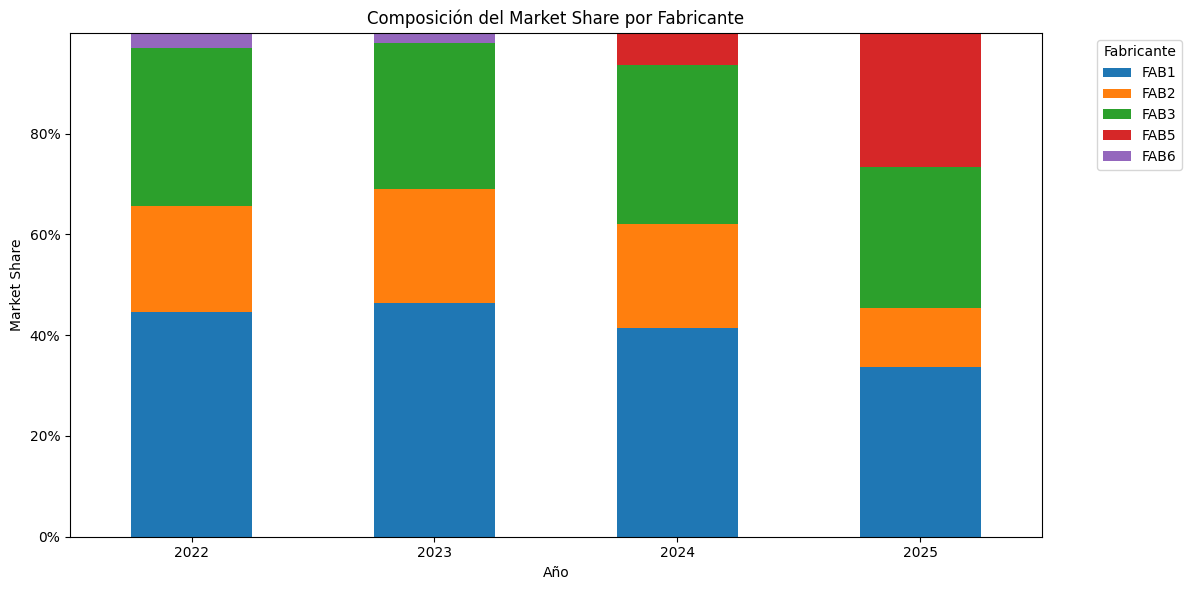

In [83]:
ax = share_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.title('Composición del Market Share por Fabricante')
plt.xlabel('Año')
plt.ylabel('Market Share')
plt.legend(
    title='Fabricante',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Observando el comportamiento del mercado, se da a entender que predomina en el transcurso de los años el fabricante 1, contiene aproximadamente el 40% de los datos en los años y recienetemente gana mayor participación el fabricante 5. El fabricante 3 se puede observar que es el segundo lugar y el fabricante 2 perdió fuerza en el transcurso de los años.

In [84]:
ultima_fecha = monthly['FECHAM'].max()

fecha_inicio = ultima_fecha - pd.DateOffset(months=11)

monthly_l12m = monthly[
    (monthly['FECHAM'] >= fecha_inicio) &
    (monthly['FECHAM'] <= ultima_fecha)
].copy()





In [87]:
fab1_l12m = monthly_l12m[
    monthly_l12m['FABRICANTE'] == 'FAB1'
]
product_sales = (
    fab1_l12m
    .groupby('PRODUCTO')['VENTA_VALOR']
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)


product_share = (
    product_sales /
    product_sales.sum()
)

print(product_share)

PRODUCTO
FAB1_Leche Clasica Entera 1 L                86884751.93
FAB1_Leche Clasica Deslactosada 1 L          85006585.93
FAB1_Leche Clasica Deslactosada Light 1 L    42840184.80
FAB1_1L  Sele En Selecta Entera              25018869.71
FAB1_1L  Sel Des Deslactosada                13399351.83
FAB1_Leche Clasica Extra Deslactosada 1 L     1951755.38
FAB1_Leche Clasica Light 1 L                   268755.67
FAB1_Leche Clasica Semi 1 L                     21450.00
Name: VENTA_VALOR, dtype: float64
PRODUCTO
FAB1_Leche Clasica Entera 1 L                0.340202
FAB1_Leche Clasica Deslactosada 1 L          0.332848
FAB1_Leche Clasica Deslactosada Light 1 L    0.167743
FAB1_1L  Sele En Selecta Entera              0.097963
FAB1_1L  Sel Des Deslactosada                0.052466
FAB1_Leche Clasica Extra Deslactosada 1 L    0.007642
FAB1_Leche Clasica Light 1 L                 0.001052
FAB1_Leche Clasica Semi 1 L                  0.000084
Name: VENTA_VALOR, dtype: float64


Se puede osbervar que para el fabricante 1, se tiene una mayor participación y es el producto principal la leche clásica entera de 1L. Sabiendo esto, se hará la regresión lineal con este producto para observar la elaasticidad del producto y como se afecta el volumen respecto a su precio unitario.


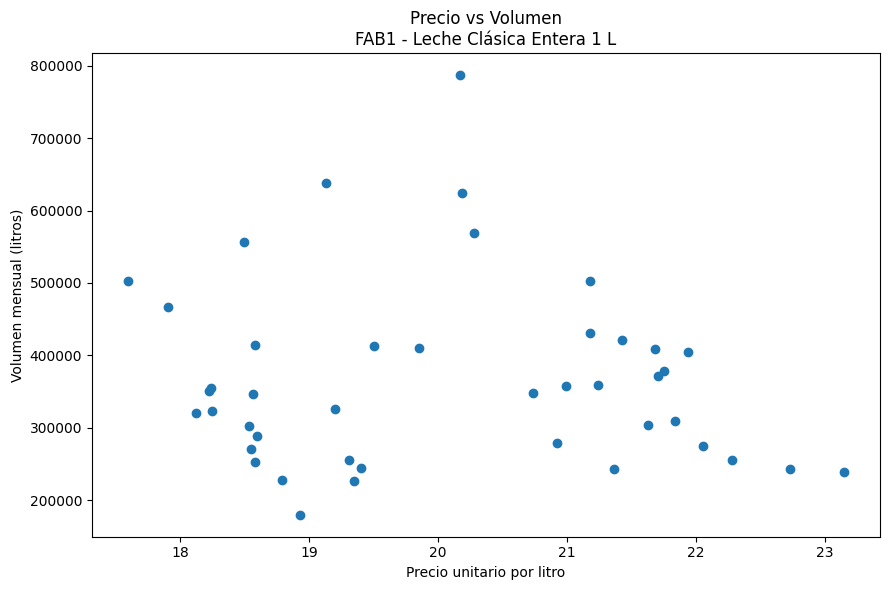

In [98]:
producto = 'FAB1_Leche Clasica Entera 1 L'

top_product = monthly[
    monthly['PRODUCTO'] == producto
].copy()



plt.figure(figsize=(9, 6))

plt.scatter(
    top_product['PPU_Litro'],
    top_product['LITROS']
)

plt.xlabel('Precio unitario por litro')
plt.ylabel('Volumen mensual (litros)')
plt.title(
    'Precio vs Volumen\nFAB1 - Leche Clásica Entera 1 L'
)

plt.tight_layout()
plt.show()

Version Lineal de regresión

In [104]:
import statsmodels.api as sm

X = top_product['PPU_Litro']
y = top_product['LITROS']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 LITROS   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.3721
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.545
Time:                        05:42:39   Log-Likelihood:                -565.82
No. Observations:                  43   AIC:                             1136.
Df Residuals:                      41   BIC:                             1139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.248e+05    2.6e+05      2.021      0.0

Versión logarítmica de regresión

In [110]:
top_product['log_litros'] = np.log(top_product['LITROS'])
top_product['log_ppu'] = np.log(top_product['PPU_Litro'])


X = top_product['log_ppu']
y = top_product['log_litros']

X = sm.add_constant(X)

elasticity_model = sm.OLS(y, X).fit()

print(elasticity_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_litros   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.2848
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.596
Time:                        05:45:32   Log-Likelihood:                -11.504
No. Observations:                  43   AIC:                             27.01
Df Residuals:                      41   BIC:                             30.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8079      1.964      7.032      0.0

Analizando ambos modelos, se puede observar que si tiene sentido el comportamiento de un producto respecto a su precio. En los dos modelos se comporta de forma inversamente lineal. Esto nos da a entender que si es que aumenta el precio del producto, se baja el volumen de venta de este mismo.

En el caos de la regresión logarímtica, nos permite verlo como una variación porcentual de volumen ante una variación porcentual de precio.

Ambos obtienen un valor cercano a 0.5 de p-value.